# Synthetischer Datensatz — Modellbildung

Lädt die Rohdaten (`data_raw`), trainiert/lädt MLP, Kalman- und Extended-Kalman-Filter, wertet den Prädiktionsfehler aus und speichert das gescorte Artefakt `data_scored` für *syn_detection*.

In [1]:
FORCE_RECOMPUTE = False
IS_FINAL = True

In [2]:
# --- Konstanten ---
RUN_ID = "55c4dfbd"   # None -> neueste data_raw

SEED = 42

WINDOW = 60
SETTLE_S = 120

ARCH = [32, 32, 1]
ACT = "tanh"
EPOCHS = 500
BATCH = 32
VAL_SPLIT = 0.2   # gruppenweise nach bp

In [3]:
import os
from pathlib import Path

work_dir = os.getcwd()
DEFAULT_BASE_DIR = os.path.normpath(os.path.join(work_dir, "..", ".."))

base_dir = Path(os.environ.get("BASE_DIR", DEFAULT_BASE_DIR)).resolve()
data_dir = base_dir / "data" / "synthetic_data"
model_dir = base_dir / "models"
plot_dir = base_dir / "plots"
results_dir = base_dir / "results"

for _d in (data_dir, model_dir, plot_dir, results_dir):
    os.makedirs(_d, exist_ok=True)  

In [4]:
from src.utils import run_registry as rr
import numpy as np

data_store  = rr.synthetic_data_store(data_dir)
model_store = rr.synthetic_model_store(model_dir)

if RUN_ID is None:
    run_id = data_store.latest_id("data_raw")
    if run_id is None:
        raise FileNotFoundError("Kein data-Artefakt. Bitte syn_generation.ipynb ausfuehren.")
else:
    run_id = RUN_ID
print(f"run_id = {run_id}")

rng = np.random.default_rng(SEED)
data = data_store.load("data_raw", run_id=run_id, rename=True, rekey=True)
run_cfg = dict(data.attrs.get("config", data.attrs))
data_cfg = rr.RunConfig(run_cfg)
data_doe = data_store.load("data_doe", data_cfg, rename=True, rekey=True)

first_win_idx = data.index[0]
last_win_idx = data.index[-1]

alpha_1, alpha_2 = run_cfg.get("alpha")
beta = run_cfg.get("beta")

ledger = rr.run_ledger(work_dir)
ledger.bind("model", parents={"data": data_cfg.base_id})
plot_store = rr.synthetic_plot_store(plot_dir, ledger=ledger)
res_store  = rr.synthetic_results_store(results_dir, ledger=ledger)

run_id = 55c4dfbd


In [5]:
model_params = {"arch": ARCH, "act": ACT, "opt": "adam",
                "epochs": EPOCHS, "batch": BATCH, "val_split": VAL_SPLIT, "seed": SEED,
                "window_size": WINDOW,
                "features": ["u1_noise_filt", "u2_noise_filt"]}
model_cfg = data_cfg.compose(model=model_params)

_model_loaded_from_cache = model_store.exists("model", model_cfg, rekey=True) and not FORCE_RECOMPUTE

In [6]:
_train_data_loaded_from_cache = (
    data_store.exists("data_train", data_cfg, rekey=True)
    and not FORCE_RECOMPUTE
)

_test_data_loaded_from_cache = (
    data_store.exists("data_test", model_cfg, rekey=True)
    and not FORCE_RECOMPUTE
)

## Vorverarbeitung

In [7]:
if _train_data_loaded_from_cache:
    train_data = data_store.load("data_train", data_cfg, rename=True, rekey=True)
else:
    _filt_cols_doe = ["u1_noise", "u2_noise", "y_noise"]
    for col in _filt_cols_doe:
        data_doe[f"{col}_filt"] = data_doe[col].rolling(window=WINDOW, center=False, min_periods=1).mean()

    local_k = data_doe.groupby("bp").cumcount()
    data_doe["stationary"] = local_k >= SETTLE_S
    train_data = data_doe[data_doe["stationary"]]
    data_store.save(train_data, "data_train", data_cfg)

# Create Models

## Train Neural network

In [8]:
if _model_loaded_from_cache:
    _mc = model_store.load("model", model_cfg, rekey=True)
    model = _mc["model"]
    X_scaler = _mc["X_scaler"]
    y_scaler = _mc["y_scaler"]
else:
    import tensorflow as tf
    from sklearn.preprocessing import MinMaxScaler, StandardScaler

    tf.keras.utils.set_random_seed(SEED)
    X_scaler = MinMaxScaler()
    y_scaler = StandardScaler()

    features = X_scaler.fit_transform(train_data[["u1_noise_filt", "u2_noise_filt"]].to_numpy())
    labels = y_scaler.fit_transform(train_data[["y_noise_filt"]].to_numpy()).ravel()

    # Gruppen-Split nach Breakpoint: Validation = komplette, ungesehene Operating Points
    bp = train_data["bp"].to_numpy()
    unique_bp = np.unique(bp)
    n_val = max(1, int(round(VAL_SPLIT * len(unique_bp))))
    val_bps = rng.choice(unique_bp, size=n_val, replace=False)
    val_mask = np.isin(bp, val_bps)

    X_tr, y_tr = features[~val_mask], labels[~val_mask]
    X_val, y_val = features[val_mask], labels[val_mask]
    perm = rng.permutation(len(X_tr))
    X_tr, y_tr = X_tr[perm], y_tr[perm]

    early_stopping = tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=50, restore_best_weights=True)
    reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=20, min_lr=1e-5)

    model = tf.keras.Sequential([
        tf.keras.layers.Dense(ARCH[0], activation=ACT, input_shape=(features.shape[1],)),
        tf.keras.layers.Dense(ARCH[1], activation=ACT),
        tf.keras.layers.Dense(ARCH[2]),
    ])
    model.compile(optimizer="adam", loss="mse")
    model.fit(X_tr, y_tr, epochs=EPOCHS, batch_size=BATCH,
            validation_data=(X_val, y_val),
            callbacks=[early_stopping, reduce_lr], verbose=2)

    model_store.save({"model": model, "X_scaler": X_scaler, "y_scaler": y_scaler, "meta": run_cfg}, "model", model_cfg)


c:\git\process_optimization_concept_drift\venv_311\Lib\site-packages\sklearn\base.py:376: InconsistentVersionWarning: Trying to unpickle estimator MinMaxScaler from version 1.7.0 when using version 1.4.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
c:\git\process_optimization_concept_drift\venv_311\Lib\site-packages\sklearn\base.py:376: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.7.0 when using version 1.4.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


Apply Neural network

In [9]:
if _test_data_loaded_from_cache:
    test_data = data_store.load("data_test", model_cfg, rename=True, rekey=True)

In [10]:
if not _test_data_loaded_from_cache:
    _filt_cols_stream = ["u1_noise", "u2_noise", "y_noise",
        "u1_cd_noise", "u2_cd_noise", "y_cd_noise"]
    for col in _filt_cols_stream:
        data[f"{col}_filt"] = data[col].rolling(window=WINDOW, center=False, min_periods=1).mean()

    stepsize = 60
    test_data = data.loc[first_win_idx:last_win_idx:stepsize]

In [11]:
if not _test_data_loaded_from_cache:
    test_features = test_data[["u1_noise_filt", "u2_noise_filt"]].to_numpy()
    test_labels = test_data["y_noise_filt"].values
    test_features_scaled = X_scaler.transform(test_features)

    y_pred = y_scaler.inverse_transform(model.predict(test_features_scaled)).ravel()
    pred_error = test_labels - y_pred

In [12]:
if not _test_data_loaded_from_cache:
    test_data = test_data.copy()
    test_data.loc[:, "y_pred"] = y_pred
    test_data.loc[:, "pred_error"] = pred_error

In [13]:
if not _test_data_loaded_from_cache:
    pred_error_norm = (pred_error - np.mean(pred_error)) / np.std(pred_error)
    pred_error_norm = np.nan_to_num(pred_error_norm)
    test_data = test_data.copy()
    test_data.loc[:, "pred_error_norm"] = pred_error_norm

In [14]:
if not _test_data_loaded_from_cache:
    test_features_cd = test_data[["u1_cd_noise_filt", "u2_cd_noise_filt"]].to_numpy()
    test_labels_cd = test_data["y_cd_noise_filt"].values
    test_features_scaled_cd = X_scaler.transform(test_features_cd)

    y_pred_cd = y_scaler.inverse_transform(model.predict(test_features_scaled_cd)).ravel()
    pred_error_cd = test_labels_cd - y_pred_cd

In [15]:
if not _test_data_loaded_from_cache:
    test_data = test_data.copy()
    test_data.loc[:, "pred_error_cd"] = pred_error_cd
    test_data.loc[:, "y_pred_cd"] = y_pred_cd

In [16]:
if not _test_data_loaded_from_cache:
    pred_error_norm_cd = (pred_error_cd - np.mean(pred_error)) / np.std(pred_error)
    pred_error_norm_cd = np.nan_to_num(pred_error_norm_cd)

In [17]:
if not _test_data_loaded_from_cache:
    test_data = test_data.copy()
    test_data.loc[:, "pred_error_norm_cd"] = pred_error_norm_cd

## Kalman-Filter

In [18]:
def g_inv(y, beta):
    """Inverse der linear-kubischen Kennlinie g(v) = v + beta*v^3 (Cardano, eindeutig wegen Monotonie)."""
    d = np.sqrt((y / (2*beta))**2 + (1 / (3*beta))**3)
    return np.cbrt(y / (2*beta) + d) + np.cbrt(y / (2*beta) - d)

def run_kf(u1_arr, u2_arr, y_arr, theta_init, P_init, Q, R, beta):
    """Linearer KF auf invertierter Messung z = g^{-1}(y); phi = [u1, u2], Random-Walk theta_{k+1} = theta_k + w."""
    n = len(u1_arr)
    theta = theta_init.copy()
    P = P_init.copy()
    innovations = np.zeros(n)
    I2 = np.eye(len(theta_init))
    z_arr = g_inv(y_arr, beta)
    for k in range(n):
        phi_k = np.array([u1_arr[k], u2_arr[k]])
        P_pred = P + Q
        innovations[k] = z_arr[k] - phi_k @ theta
        S_k = phi_k @ P_pred @ phi_k + R
        K_k = (P_pred @ phi_k) / S_k
        theta = theta + K_k * innovations[k]
        P = (I2 - np.outer(K_k, phi_k)) @ P_pred
    return innovations

In [19]:
if not _test_data_loaded_from_cache:
    train_kf = train_data
    phi_train_kf = np.stack([train_kf["u1_noise_filt"], train_kf["u2_noise_filt"]], axis=1)
    z_train = g_inv(train_kf["y_noise_filt"].to_numpy(), beta)
    theta_kf_init, _, _, _ = np.linalg.lstsq(phi_train_kf, z_train, rcond=None)
    resid_kf = z_train - phi_train_kf @ theta_kf_init
    R_kf  = float(np.var(resid_kf))
    Q_kf  = 1e-10 * np.eye(2)
    P_kf_init = 1e-4 * np.eye(2)

    u1_t  = test_data["u1_noise_filt"].to_numpy()
    u2_t  = test_data["u2_noise_filt"].to_numpy()
    y_t   = test_data["y_noise_filt"].to_numpy()
    kf_innov = run_kf(u1_t,    u2_t,    y_t,    theta_kf_init, P_kf_init, Q_kf, R_kf, beta)
    
    u1_cd_t = test_data["u1_cd_noise_filt"].to_numpy()
    u2_cd_t = test_data["u2_cd_noise_filt"].to_numpy()
    y_cd_t  = test_data["y_cd_noise_filt"].to_numpy()
    kf_innov_cd = run_kf(u1_cd_t, u2_cd_t, y_cd_t, theta_kf_init, P_kf_init, Q_kf, R_kf, beta)

    kf_innov_norm    = (kf_innov    - np.mean(kf_innov))    / np.std(kf_innov)
    kf_innov_norm_cd = (kf_innov_cd - np.mean(kf_innov)) / np.std(kf_innov)
    kf_innov_norm    = np.nan_to_num(kf_innov_norm)
    kf_innov_norm_cd = np.nan_to_num(kf_innov_norm_cd)

    test_data = test_data.copy()
    test_data.loc[:, "kf_innov"]    = kf_innov
    test_data.loc[:, "kf_innov_cd"] = kf_innov_cd
    test_data.loc[:, "kf_innov_norm"]    = kf_innov_norm
    test_data.loc[:, "kf_innov_norm_cd"] = kf_innov_norm_cd

## Extended Kalman-Filter

In [20]:
def run_ekf(u1_arr, u2_arr, y_arr, theta_init, P_init, Q, R, beta):
    """EKF; Beobachtung h(theta) = g(theta[0]*u1 + theta[1]*u2) mit g(v) = v + beta*v^3, Random-Walk-Zustand."""
    n = len(u1_arr)
    theta = theta_init.copy()
    P = P_init.copy()
    innovations = np.zeros(n)
    I2 = np.eye(2)
    for k in range(n):
        u1_k, u2_k = u1_arr[k], u2_arr[k]
        P_pred = P + Q
        v_k    = theta[0]*u1_k + theta[1]*u2_k
        y_pred = v_k + beta * v_k**3
        H_k    = (1 + 3 * beta * v_k**2) * np.array([u1_k, u2_k])
        S_k    = H_k @ P_pred @ H_k + R
        K_k    = (P_pred @ H_k) / S_k
        innovations[k] = y_arr[k] - y_pred
        theta = theta + K_k * innovations[k]
        P = (I2 - np.outer(K_k, H_k)) @ P_pred
    return innovations

In [21]:
if not _test_data_loaded_from_cache:
    v_train    = phi_train_kf @ theta_kf_init          # phi_train_kf = [u1, u2] aus dem KF-Block
    resid_ekf  = train_kf["y_noise_filt"].to_numpy() - (v_train + beta * v_train**3)
    R_ekf      = float(np.var(resid_ekf))

    theta_ekf_init = np.array([alpha_1, alpha_2])      
    Q_ekf      = 1e-10 * np.eye(2)
    P_ekf_init = 1e-4 * np.eye(2)

    ekf_innov_cd = run_ekf(u1_cd_t, u2_cd_t, y_cd_t, theta_ekf_init, P_ekf_init, Q_ekf, R_ekf, beta)
    ekf_innov    = run_ekf(u1_t,    u2_t,    y_t,    theta_ekf_init, P_ekf_init, Q_ekf, R_ekf, beta)

    ekf_innov_norm    = (ekf_innov    - np.mean(ekf_innov))    / np.std(ekf_innov)
    ekf_innov_norm_cd = (ekf_innov_cd - np.mean(ekf_innov)) / np.std(ekf_innov)
    ekf_innov_norm    = np.nan_to_num(ekf_innov_norm)
    ekf_innov_norm_cd = np.nan_to_num(ekf_innov_norm_cd)

    test_data = test_data.copy()
    test_data.loc[:, "ekf_innov"]    = ekf_innov
    test_data.loc[:, "ekf_innov_cd"] = ekf_innov_cd
    test_data.loc[:, "ekf_innov_norm"]    = ekf_innov_norm
    test_data.loc[:, "ekf_innov_norm_cd"] = ekf_innov_norm_cd

In [22]:
if not _test_data_loaded_from_cache:
    data_store.save(test_data, "data_test", model_cfg)

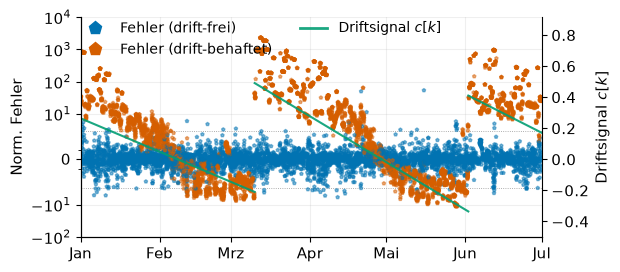

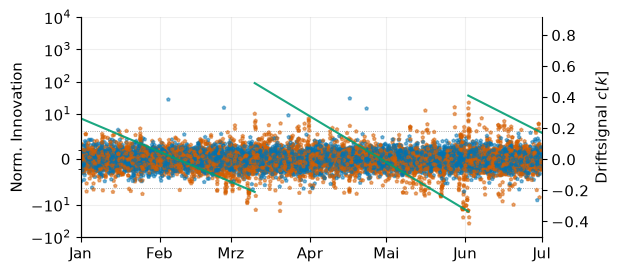

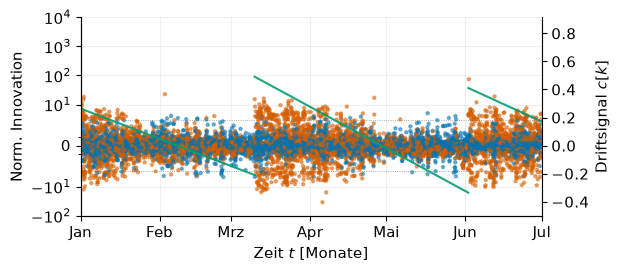

In [23]:
import pandas as pd
import matplotlib.pyplot as plt
from src.utils import thesis_style as ts

PLOT_END = pd.Timestamp("1970-07-01")
td = test_data.loc[:PLOT_END]

models = [
    ("mlp", "Norm. Fehler",     "pred_error_norm", "pred_error_norm_cd"),
    ("kf",  "Norm. Innovation", "kf_innov_norm",   "kf_innov_norm_cd"),
    ("ekf", "Norm. Innovation", "ekf_innov_norm",  "ekf_innov_norm_cd"),
]

rng_plot = np.random.default_rng(SEED)

for j, (name, ylabel, col_base, col_cd) in enumerate(models):
    fig, ax, ax2 = ts.error_timeseries(
        td.index,
        [(td[col_base].values, "drift_free",      "Fehler (drift-frei)"),
         (td[col_cd].values,   "drift_afflicted", "Fehler (drift-behaftet)")],
        cd=td["cd"].values,
        ylabel=ylabel,
        xlabel="Zeit $t$ [Monate]" if j == len(models) - 1 else None,
        ylim=(-1e2, 1e4), frac=0.02, rng=rng_plot,
        cd_amp=0.5, cd_tick_step=0.2, height_scale=0.45,
        legend=dict(bbox_to_anchor=[0.81, 0.9], loc="center right", ncols=2, 
                    markerscale=1) if j == 0 else False,
    )
    fig.tight_layout()
    plot_store.save_figure(fig, f"model_error_{name}", model_cfg, final=IS_FINAL, savefig_kwargs={"dpi": 300}, archive_kwargs={"dpi": 300})
    plt.show()


In [24]:
# --- Diagnose: Quelle der extremen drift-behafteten Ausreisser ---
# Frage: Sind die -300sigma-Spitzen echte Prozesszustaende (y_cd extrem)
# oder Modell-Extrapolation (y_pred_cd schiesst aus)?

import numpy as np
import pandas as pd

_mask = test_data.index <= pd.Timestamp("1970-07-01")
td = test_data.loc[_mask]

# Trainingsbereich des Scalers (auf drift-freiem DOE gefittet)
feat_min = X_scaler.data_min_
feat_max = X_scaler.data_max_

u1_cd = td["u1_cd_noise_filt"].to_numpy()
u2_cd = td["u2_cd_noise_filt"].to_numpy()
y_cd  = td["y_cd_noise_filt"].to_numpy()
y_hat = td["y_pred_cd"].to_numpy()
err   = td["pred_error_cd"].to_numpy()   # = y_hat - y_cd

# Anteil der Eingaenge ausserhalb des Trainingsbereichs [min, max]
oor_u1 = (u1_cd < feat_min[0]) | (u1_cd > feat_max[0])
oor_u2 = (u2_cd < feat_min[1]) | (u2_cd > feat_max[1])
oor_any = oor_u1 | oor_u2

print(f"Scaler-Trainingsbereich  u1: [{feat_min[0]:.4g}, {feat_max[0]:.4g}]  "
      f"u2: [{feat_min[1]:.4g}, {feat_max[1]:.4g}]")
print(f"Eingaenge ausserhalb (u1 | u2): {100*oor_any.mean():.1f} %\n")

# Die 10 groessten Ausreisser nach |Fehler|
k = 10
idx = np.argsort(-np.abs(err))[:k]
diag = pd.DataFrame({
    "zeit":       td.index[idx],
    "u1_cd":      u1_cd[idx],
    "u2_cd":      u2_cd[idx],
    "u1_oor":     oor_u1[idx],   # Eingang ausserhalb Trainingsbereich?
    "u2_oor":     oor_u2[idx],
    "y_true":     y_cd[idx],
    "y_pred":     y_hat[idx],
    "fehler":     err[idx],
}).reset_index(drop=True)

pd.set_option("display.float_format", lambda v: f"{v:.4g}")
print("Top-Ausreisser (drift-behaftet):")
print(diag.to_string(index=False))

# Zerlegung: Wie extrem sind y_true vs. y_pred im Vergleich zum drift-freien Normalbetrieb?
y_ref = td["y_noise_filt"].to_numpy()          # drift-freie Zielgroesse
print(f"\ny_true  drift-frei:      Bereich [{y_ref.min():.4g}, {y_ref.max():.4g}]")
print(f"y_true  drift-behaftet:  Bereich [{y_cd.min():.4g}, {y_cd.max():.4g}]")
print(f"y_pred  drift-behaftet:  Bereich [{y_hat.min():.4g}, {y_hat.max():.4g}]")

# Verdikt: liegt der Fehler eher an ausufernder Vorhersage oder an extremem Ziel?
big = np.abs(err) > 5 * np.std(td["pred_error"].to_numpy())   # >5sigma des drift-freien Fehlers
share_pred = np.mean(np.abs(y_hat[big] - np.median(y_ref)) >
                     np.abs(y_cd[big]  - np.median(y_ref)))
print(f"\nAnteil grosser Ausreisser, bei denen y_pred weiter vom Normalwert "
      f"entfernt ist als y_true: {100*share_pred:.0f} %")
print("-> hoher Wert = Modell-Extrapolation dominiert; "
      "niedriger Wert = echte Prozess-Extremzustaende.")

Scaler-Trainingsbereich  u1: [0.004372, 5.02]  u2: [0.01771, 9.952]
Eingaenge ausserhalb (u1 | u2): 43.7 %

Top-Ausreisser (drift-behaftet):
               zeit  u1_cd  u2_cd  u1_oor  u2_oor  y_true  y_pred  fehler
1970-03-12 12:34:00  9.975  17.33    True    True   207.2   68.11   139.1
1970-03-12 12:37:00  9.978  17.32    True    True   207.2   68.11   139.1
1970-03-12 12:36:00     10  17.32    True    True   207.2   68.13   139.1
1970-03-12 12:42:00  9.988  17.32    True    True   207.2   68.12   139.1
1970-03-12 12:33:00  10.02  17.31    True    True   207.3   68.15   139.1
1970-03-12 12:39:00  10.01  17.32    True    True   207.2   68.14   139.1
1970-03-12 12:35:00  10.02  17.32    True    True   207.2   68.15   139.1
1970-03-12 12:40:00  10.01  17.32    True    True   207.2   68.14   139.1
1970-03-12 12:52:00  9.982  17.31    True    True   207.2   68.11   139.1
1970-03-12 12:41:00  10.01  17.32    True    True   207.2   68.14   139.1

y_true  drift-frei:      Bereich [0.1488, 34

## Numerische Auswertung der Modelldegradation

In [25]:
import numpy as np
import pandas as pd

_mask6 = (test_data.index <= pd.Timestamp("1970-07-01"))
c_test = test_data["cd"].to_numpy()[_mask6]
residuals = {
    "MLP": (test_data["pred_error"].to_numpy()[_mask6], test_data["pred_error_cd"].to_numpy()[_mask6]),
    "KF":  (test_data["kf_innov"].to_numpy()[_mask6],   test_data["kf_innov_cd"].to_numpy()[_mask6]),
    "EKF": (test_data["ekf_innov"].to_numpy()[_mask6],  test_data["ekf_innov_cd"].to_numpy()[_mask6]),
}

def _stats(r0, r1, c):
    r0 = np.asarray(r0, float); r1 = np.asarray(r1, float); c = np.asarray(c, float)
    return dict(
        rmse_driftfree=np.sqrt(np.mean(r0**2)),
        rmse_drift=np.sqrt(np.mean(r1**2)),
        std_driftfree=np.std(r0),
        bias_drift=np.mean(r1),
        std_drift=np.std(r1),
        corr_base=np.corrcoef(r0, c)[0, 1],
        corr_abs=np.corrcoef(np.abs(r1), np.abs(c))[0, 1],
    )

stats = pd.DataFrame({m: _stats(r0, r1, c_test) for m, (r0, r1) in residuals.items()}).T
pd.set_option("display.float_format", lambda v: f"{v:.4g}")
print(stats.to_string())

     rmse_driftfree  rmse_drift  std_driftfree  bias_drift  std_drift  corr_base  corr_abs
MLP         0.06484       15.09        0.06445       4.492      14.41    0.01191    0.4537
KF         0.008984     0.01509       0.008984  -0.0008056    0.01507  -0.000818    0.1195
EKF         0.06125      0.1568        0.06124  -0.0006974     0.1568  -0.001631    0.2917


## Ergebnisse speichern

In [26]:
from src.utils import results_export as rx

_keys = [(k, k, "num") for k in
         ["rmse_driftfree", "rmse_drift", "std_driftfree", "bias_drift",
          "std_drift", "corr_base", "corr_abs"]]

(rx.ResultDoc()
   .integer("n_samples", len(test_data))
   .stats(stats, _keys, into="models")
   .save(res_store, "model_error", model_cfg, final=IS_FINAL))

Umfassende Ergebnisse -> C:\git\process_optimization_concept_drift\results\syn_model_error.json


'C:\\git\\process_optimization_concept_drift\\results\\syn_model_error.json'

In [27]:
from src.utils import latex_export as lx

mx = lx.MacroExport("automatisch erzeugt aus syn_model.ipynb - nicht manuell editieren")

mx.comment("Parameter (Hash-relevant, Sektion 'model')")
mx.param("paramWindow", model_params["window_size"], unit=r"\second")
mx.param("paramEpochs", model_params["epochs"])
mx.param("paramBatch", model_params["batch"])
mx.param("paramValSplitPct", round(model_params["val_split"] * 100))
mx.param("paramNeurons", model_params["arch"][0])
mx.param("paramNLayers", len(model_params["arch"]) - 1, spell_out=True)

mx.comment("Ergebnisse (Modellfehler-Statistiken)")
mx.stats(stats, [("rmse_driftfree", "RmseFree", 3), ("rmse_drift", "RmseDrift", 3),
                 ("std_driftfree", "SigmaFree", 3), ("bias_drift", "Bias", 3),
                 ("std_drift", "Sigma", 3), ("corr_base", "CorrBase", 2),
                 ("corr_abs", "CorrAbs", 2)], prefix="stat")

mx.save(res_store, "model_error", model_cfg, final=IS_FINAL)

LaTeX-Makros -> C:\git\process_optimization_concept_drift\results\syn_model_error.tex

% automatisch erzeugt aus syn_model.ipynb - nicht manuell editieren

% Parameter (Hash-relevant, Sektion 'model')
\newcommand{\paramWindow}{\SI{60}{\second}}
\newcommand{\paramEpochs}{500}
\newcommand{\paramBatch}{32}
\newcommand{\paramValSplitPct}{20}
\newcommand{\paramNeurons}{32}
\newcommand{\paramNLayers}{zwei}

% Ergebnisse (Modellfehler-Statistiken)
\newcommand{\statMLPRmseFree}{0{,}065}
\newcommand{\statMLPRmseDrift}{15{,}090}
\newcommand{\statMLPSigmaFree}{0{,}064}
\newcommand{\statMLPBias}{4{,}492}
\newcommand{\statMLPSigma}{14{,}406}
\newcommand{\statMLPCorrBase}{0{,}01}
\newcommand{\statMLPCorrAbs}{0{,}45}
\newcommand{\statKFRmseFree}{0{,}009}
\newcommand{\statKFRmseDrift}{0{,}015}
\newcommand{\statKFSigmaFree}{0{,}009}
\newcommand{\statKFBias}{-0{,}001}
\newcommand{\statKFSigma}{0{,}015}
\newcommand{\statKFCorrBase}{-0{,}00}
\newcommand{\statKFCorrAbs}{0{,}12}
\newcommand{\statEKFRmseFree

'C:\\git\\process_optimization_concept_drift\\results\\syn_model_error.tex'

In [28]:
from src.utils.dialogs import show_with_copy_button

show_with_copy_button(
    "Lauf abgeschlossen",
    f"Simulation beendet.\nModel Run-ID: {model_cfg.id}",
    copy_value=model_cfg.id,
)


--- Lauf abgeschlossen ---
Simulation beendet.
Model Run-ID: e7f8df2f

